In [5]:
import pandas as pd
import numpy as np

# cargar datos

df = pd.read_csv("penguins.csv", encoding="latin1")

# renombrar columnas
df.columns = [
    "species",
    "island",
    "bill_length",
    "bill_depth",
    "flipper_length",
    "body_mass",
    "sex",
]

# reemplazar NA
df.replace("NA", np.nan, inplace=True)

# unificar sexo
df["sex"] = df["sex"].replace({
    "hombre":"male",
    "masculino":"male",
    "macho":"male",
    "mujer":"female",
    "hembra":"female"
})

# eliminar filas con NA
df = df.dropna()

df.head()

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


EDA

| Gráfico   | Pregunta                                              | Variables usadas                                   |
| --------- | ----------------------------------------------------- | -------------------------------------------------- |
| Countplot | ¿Cuántos hay de cada especie?                         | species                                            |
| Boxplot   | ¿Cómo varía el peso por especie?                      | species, body_mass                                 |
| Heatmap   | ¿Cómo se relacionan las variables numéricas entre sí? | bill_length, bill_depth, flipper_length, body_mass |
| Scatter   | ¿Hay relación entre aletas y peso según especie?      | flipper_length, body_mass, species (hue)           |


<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   species         334 non-null    object 
 1   island          334 non-null    object 
 2   bill_length     334 non-null    float64
 3   bill_depth      334 non-null    float64
 4   flipper_length  334 non-null    float64
 5   body_mass       334 non-null    float64
 6   sex             334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


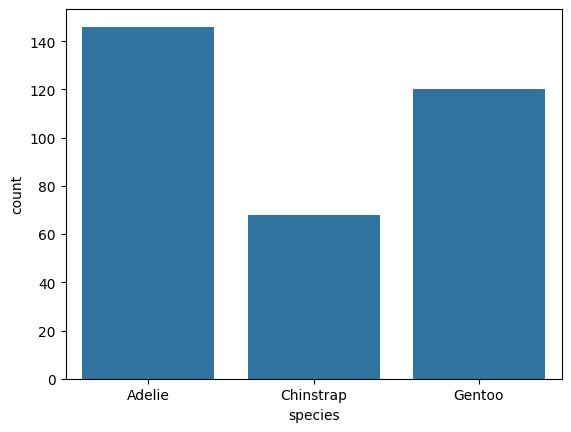

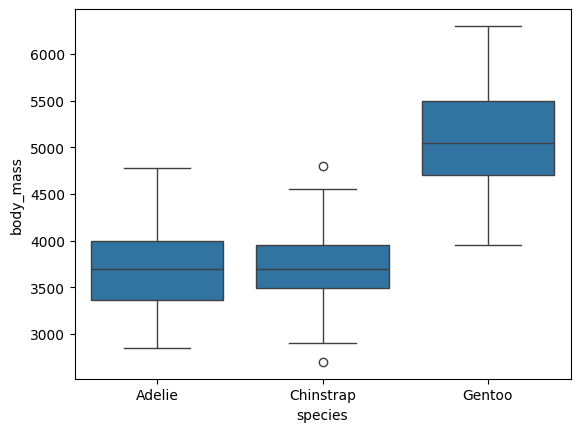

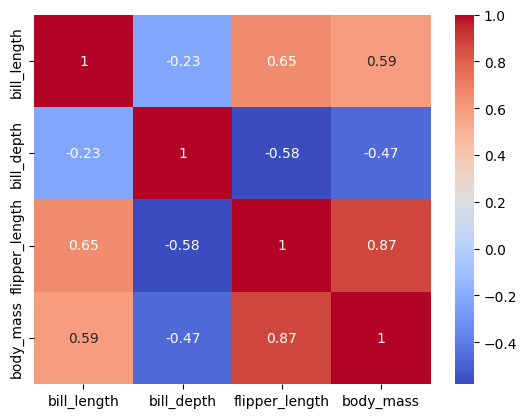

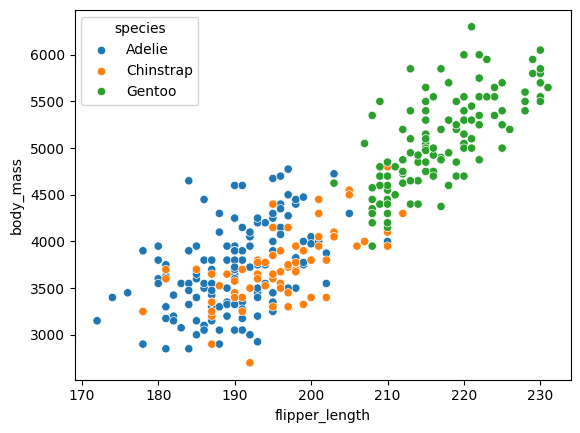

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# información general
df.info()

# estadísticas
df.describe()

# conteo por especie
sns.countplot(x="species", data=df)
plt.show()

# masa corporal por especie
sns.boxplot(x="species", y="body_mass", data=df)
plt.show()

# correlaciones
corr = df[["bill_length","bill_depth","flipper_length","body_mass"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# scatter
sns.scatterplot(x="flipper_length", y="body_mass", hue="species", data=df)
plt.show()

**REGRESION LINEAL**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np  # necesario para la raíz cuadrada

# Selección de variables
X = df[["bill_length", "bill_depth", "flipper_length"]]
y = df["body_mass"]

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamiento del modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
pred = model.predict(X_test)

# Métricas
r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))  # cálculo manual de RMSE

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.774737081500625
RMSE: 370.9434743833845


R² ≈ 0.77 → bastante buena capacidad predictiva

RMSE ≈ 371 → un error promedio de 371g representa aproximadamente el 8% del rango total — eso es perfectamente aceptable.

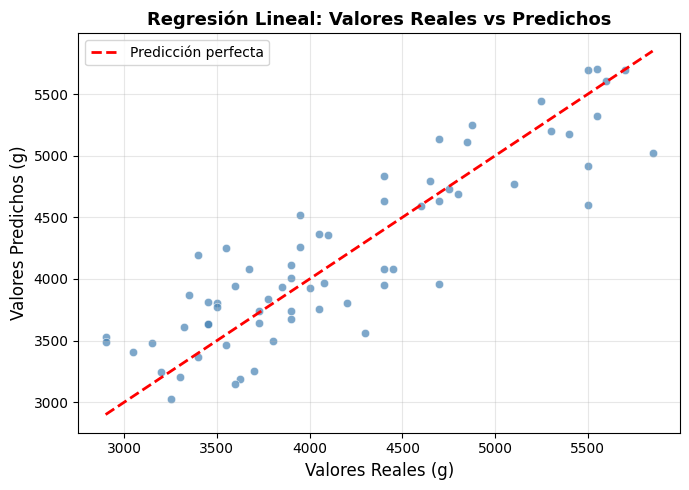

         Variable  Coeficiente
0     bill_length     3.156986
1      bill_depth    13.312161
2  flipper_length    50.760740


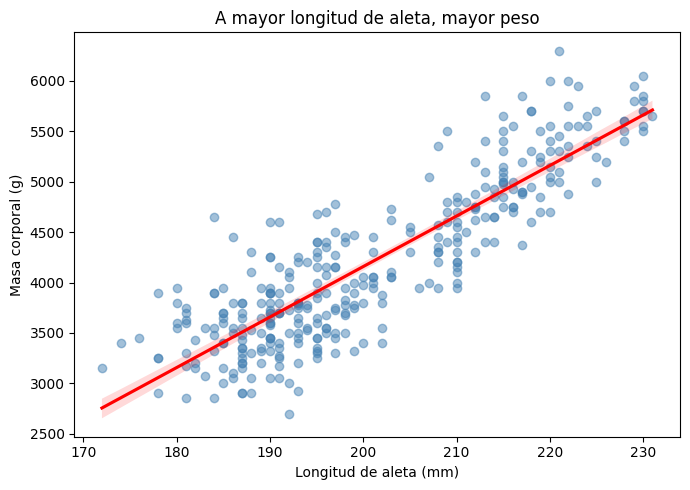

In [18]:
import matplotlib.pyplot as plt

# Gráfica: Valores Reales vs Predichos
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred, color='steelblue', alpha=0.7, edgecolors='white', linewidth=0.5)

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción perfecta')

plt.xlabel('Valores Reales (g)', fontsize=12)
plt.ylabel('Valores Predichos (g)', fontsize=12)
plt.title('Regresión Lineal: Valores Reales vs Predichos', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

coef_lineal = pd.DataFrame({'Variable': X.columns, 'Coeficiente': model.coef_})
print(coef_lineal)

# Relación entre longitud de aleta y peso
plt.figure(figsize=(7, 5))
sns.regplot(x='flipper_length', y='body_mass', data=df,
            scatter_kws={'alpha':0.5, 'color':'steelblue'},
            line_kws={'color':'red'})
plt.title('A mayor longitud de aleta, mayor peso')
plt.xlabel('Longitud de aleta (mm)')
plt.ylabel('Masa corporal (g)')
plt.tight_layout()
plt.show()

**REGRESION LOGISTICA**

Qué hace este código:

Carga tus datos.

* Limpia la columna sex de valores NA o .

* Rellena los NA numéricos con la mediana.

* Convierte MALE → 1 y FEMALE → 0.

* Escala las variables.

* Entrena una regresión logística.

* Evalúa precisión y matriz de confusión.



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Usar el df ya limpio de la celda 0 (sin re-leer el CSV)
# Las columnas ya están renombradas: bill_length, bill_depth, flipper_length, body_mass

# Normalizar la columna 'sex' y eliminar valores inválidos
df_log = df.copy()
df_log['sex'] = df_log['sex'].astype(str).str.upper()
df_log = df_log[df_log['sex'].isin(['MALE', 'FEMALE'])]

# Mapear 'sex' a binario: MALE=1, FEMALE=0
df_log['sex'] = df_log['sex'].map({'MALE': 1, 'FEMALE': 0})

# Definir X e y con los nombres de columnas correctos
num_cols = ['bill_length', 'bill_depth', 'flipper_length', 'body_mass']
X = df_log[num_cols]
y = df_log['sex']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Rellenar NA con la mediana SOLO calculada sobre entrenamiento (evita data leakage)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Escalar variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar regresión logística
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Predecir
pred = log_model.predict(X_test_scaled)

# Resultados
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))


Accuracy: 0.8805970149253731
Confusion Matrix:
 [[32  5]
 [ 3 27]]


El accuracy (exactitud) es la proporción de predicciones correctas que hizo tu modelo sobre el total de datos de prueba.

En tu caso, 0.8806 significa que el 88.06% de las predicciones del modelo fueron correctas.

Es un buen resultado, cerca del 90%.

|                 | Predicho 0 (FEMALE) | Predicho 1 (MALE) |
| --------------- | ------------------- | ----------------- |
| Real 0 (FEMALE) | 32                  | 5                 |
| Real 1 (MALE)   | 3                   | 27                |

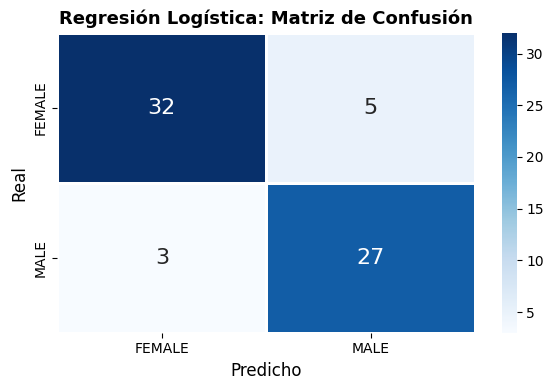

         Variable  Coeficiente
0     bill_length     0.497110
1      bill_depth     3.142409
2  flipper_length     0.056274
3       body_mass     2.954078


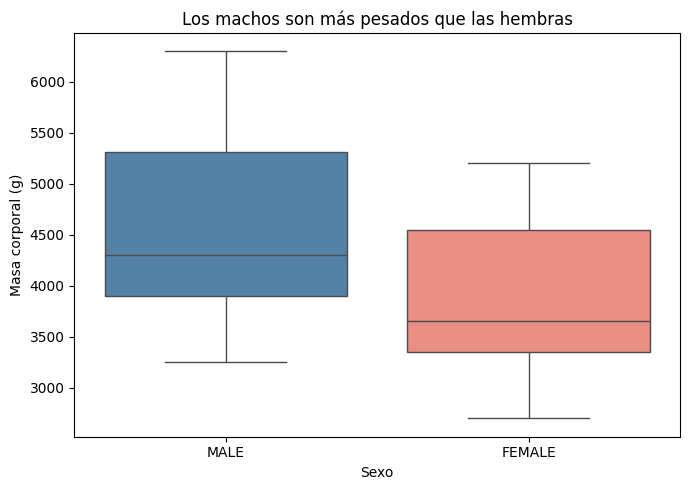

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gráfica: Matriz de Confusión
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FEMALE', 'MALE'],
            yticklabels=['FEMALE', 'MALE'],
            linewidths=1, linecolor='white', annot_kws={'size': 16})

plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Regresión Logística: Matriz de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

coef_logistica = pd.DataFrame({'Variable': num_cols, 'Coeficiente': log_model.coef_[0]})
print(coef_logistica)

# Peso según sexo
plt.figure(figsize=(7, 5))
sns.boxplot(x='sex', y='body_mass',
            data=df_log.assign(sex=df_log['sex'].map({1:'MALE', 0:'FEMALE'})),
            hue='sex', palette={'MALE':'steelblue', 'FEMALE':'salmon'},
            legend=False)
plt.title('Los machos son más pesados que las hembras')
plt.xlabel('Sexo')
plt.ylabel('Masa corporal (g)')
plt.tight_layout()
plt.show()